## MCMC sampling

In this example, we show how to sample our trained surrogate model using both the `emcee` and `dynesty` samplers. 

In [1]:
%matplotlib inline
from functools import partial
import alabi

First, we need to define the same function that was used when creating the cached model, then we can reload our results from the previous tutorial:

In [2]:
# Redefine in this notebook so that pickle file can be loaded
from scipy.optimize import rosen

def rosenbrock_fn(x):
    return -rosen(x)/100.0

bounds = [(-5,5), (-5,5)]
param_names = ['x1', 'x2']

In [3]:
import os
if not os.path.exists("results/rosenbrock_2d/surrogate_model.pkl"):
    sm_tmp = alabi.SurrogateModel(lnlike_fn=rosenbrock_fn, bounds=bounds,
                                  param_names=param_names,
                                  savedir="results/rosenbrock_2d", cache=True)
    sm_tmp.init_samples(ntrain=100, ntest=1000, sampler="sobol")
    sm_tmp.init_gp(kernel="ExpSquaredKernel", fit_amp=True, fit_mean=True,
                   white_noise=-12, gp_opt_method="l-bfgs-b")
    sm_tmp.active_train(niter=100, algorithm="bape", gp_opt_freq=20)
    del sm_tmp
sm = alabi.load_model_cache("results/rosenbrock_2d")

### Sampling with `emcee`

First, let's run emcee with default settings (uniform prior):

In [4]:
import alabi.utility as ut

# In this example we will set up a uniform prior within the parameter bounds
prior_fn = partial(ut.lnprior_uniform, bounds=sm.bounds)  # Use bounds from loaded model

sm.run_emcee(
    like_fn=sm.surrogate_log_likelihood,    # use like_fn=sm.true_log_likelihood to sample the true function
    prior_fn=prior_fn,                      # if None, defaults to uniform prior within bounds
    nwalkers=10,
    nsteps=int(2e4),
    burn=int(1e3),
    multi_proc=True,
)

Running emcee with 10 walkers for 20000 steps on 1 cores...

Run 1: Need 10000 more samples...


  0%|          | 0/20000 [00:00<?, ?it/s]

100%|██████████| 20000/20000 [01:47<00:00, 185.87it/s]


burn-in estimate: 346
thin estimate: 37

Run 1 complete: 5130 samples
Total accumulated samples: 5130

Run 2: Need 4870 more samples...


100%|██████████| 20000/20000 [01:48<00:00, 184.49it/s]

burn-in estimate: 328
thin estimate: 35

Run 2 complete: 5420 samples
Total accumulated samples: 10550

Combined 2 runs into 10550 total samples
Total samples: 10550
Mean acceptance fraction: 0.531
Mean autocorrelation time: 117.597 steps
Caching model to results/rosenbrock_2d/surrogate_model...
Saving final emcee samples to results/rosenbrock_2d/emcee_samples_final_likelihood_iter_100.npz ...


Plotting emcee posterior...
Saving to  results/rosenbrock_2d/emcee__posterior_likelihood.png


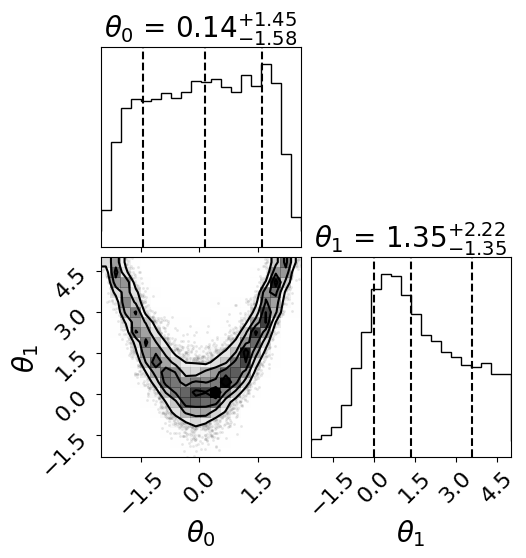

In [5]:
sm.plot(plots=["emcee_corner"]);

### Sampling with `dynesty`

Now let's use the `dynesty` nested sampler for comparison with default settings (uniform prior):

In [ ]:
# Set up uniform prior - dynesty requires separate prior transform function
prior_transform = partial(ut.prior_transform_uniform, bounds=sm.bounds)  # Use bounds from loaded model

dynesty_sampler_kwargs = {"bound": "single",
                          "nlive": 100,
                          "sample": "auto"}

dynesty_run_kwargs = {"wt_kwargs": {'pfrac': 1.0},      # set weights to 100% posterior, 0% evidence
                      "stop_kwargs": {'pfrac': 1.0},
                      "maxiter": int(2e4),
                      "dlogz_init": 0.5}
    
sm.run_dynesty(like_fn=sm.surrogate_log_likelihood,    # use like_fn=sm.true_log_likelihood to sample the true function
               prior_transform=prior_transform,        # if None, defaults to uniform prior within bounds
               multi_proc=False,                       # optional parallelization (oftentimes not worth it for dynesty)
               sampler_kwargs=dynesty_sampler_kwargs, 
               run_kwargs=dynesty_run_kwargs)

Initializing dynesty with self.surrogate_log_likelihood surrogate model as likelihood.
Initialized dynesty DynamicNestedSampler.
Running dynesty with 100 live points on 1 cores...

Run 1: Need 10000 more samples...


2569it [00:16, 191.40it/s, batch: 9 | bound: 12 | nc: 14 | ncall: 28855 | eff(%):  8.743 | loglstar: -3.790 < -0.178 < -0.085 | logz: -2.234 +/-  0.067 | stop:  5.025]       

Plotting dynesty posterior...


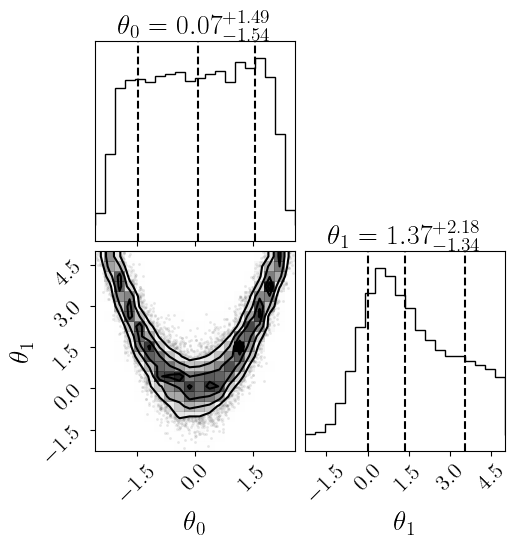

In [ ]:
sm.plot(plots=["dynesty_corner"]);

Plotting dynesty traceplot...


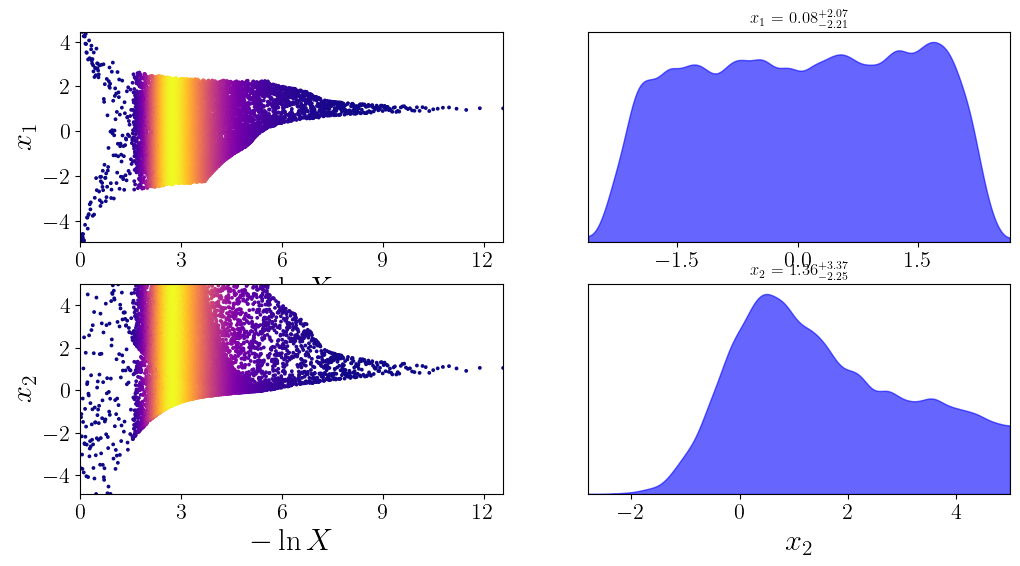

In [ ]:
sm.plot(plots=["dynesty_traceplot"]);

Plotting dynesty runplot...


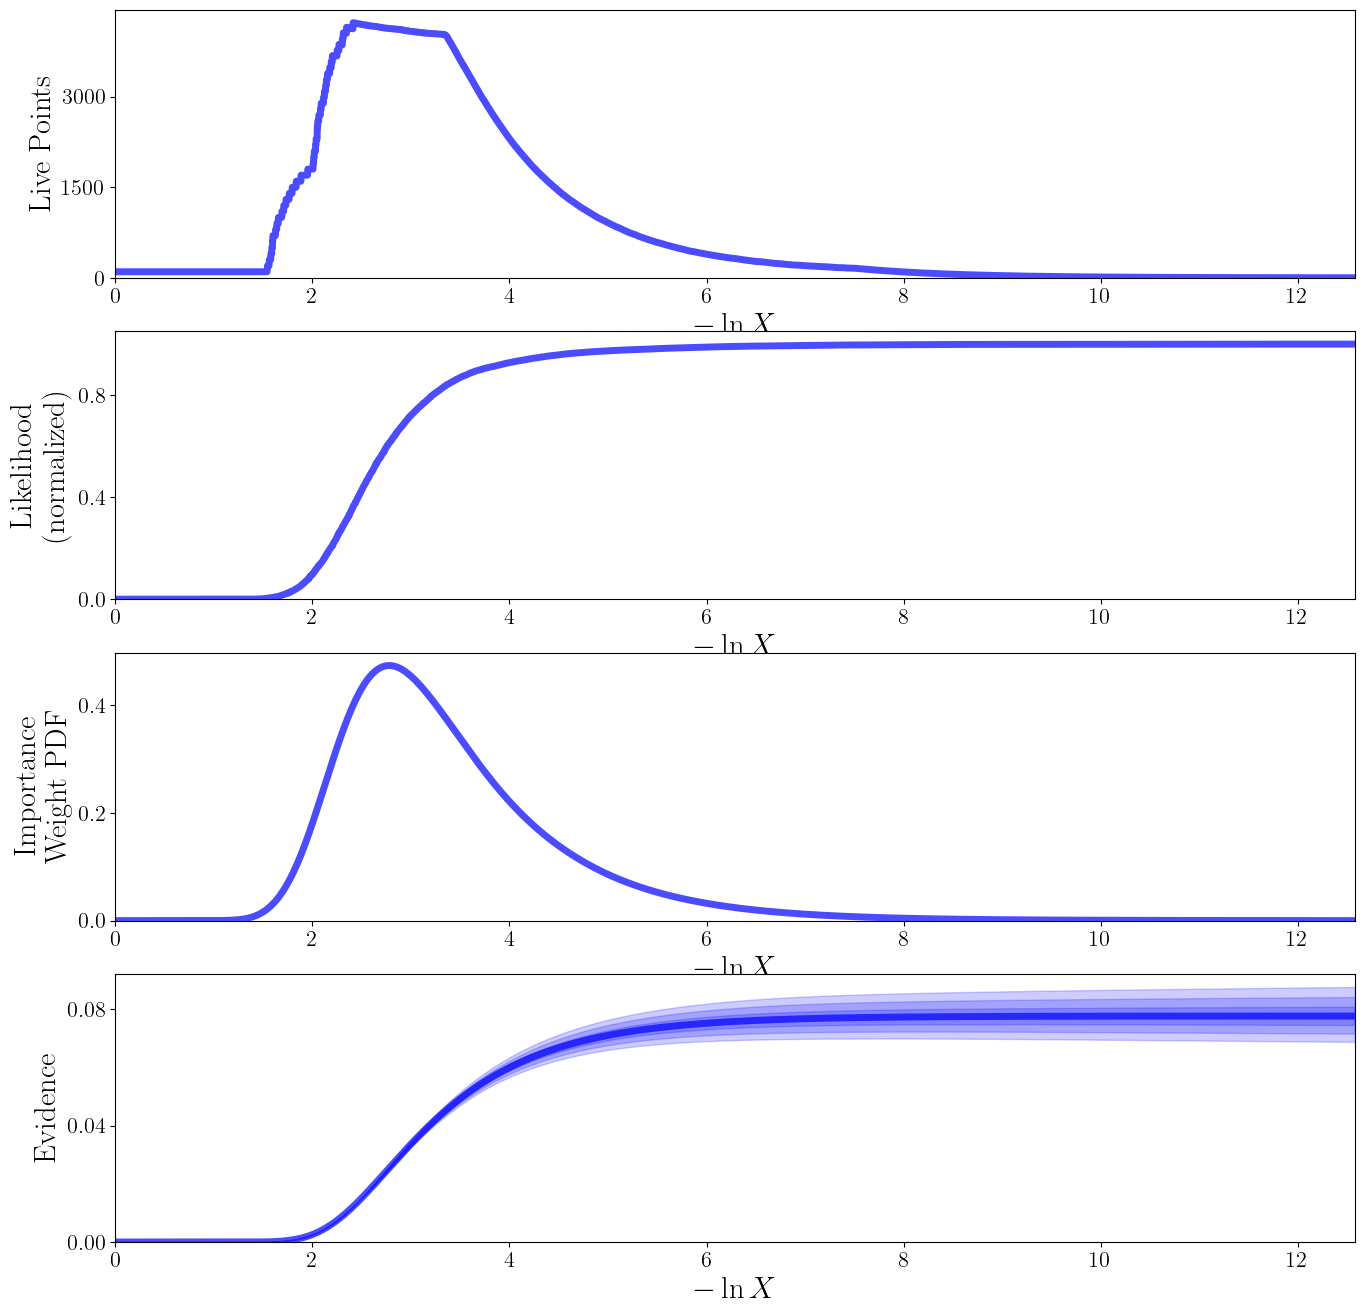

In [ ]:
sm.plot(plots=["dynesty_runplot"]);

Compare the results from both samplers:

Plotting emcee vs dynesty posterior comparison...


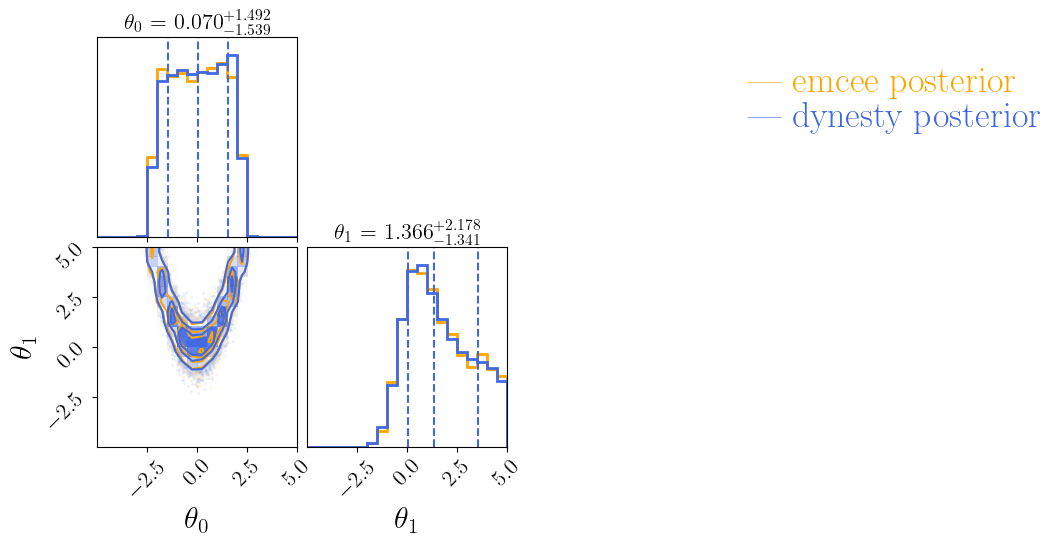

In [ ]:
sm.plot(plots=["mcmc_comparison"]);

Both samplers achieve similar results for this example!